breast_cancer_clinical3.csv读取成功
------------
df数据结构：
  Patient_ID  Age  Tumor_Size  Ki67  ER  PR  HER2  Lymph_Node TNM_Stage  \
0       P001   45         2.1    10   1   1     1           0        II   
1       P002   52         3.5    15   1   1     1           1       III   
2       P003   38         1.8    20   1   0     0           0         I   
3       P004   61         4.2    30   0   0     1           0       III   
4       P005   49         2.9    40   1   1     0           1        II   

  Molecular_Subtype  
0         Luminal_A  
1         Luminal_B  
2         Luminal_A  
3     HER2_positive  
4         Luminal_A  
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         20 non-null     str    
 1   Age                20 non-null     int64  
 2   Tumor_Size         20 non-null     float64
 3   Ki67               20 non-n

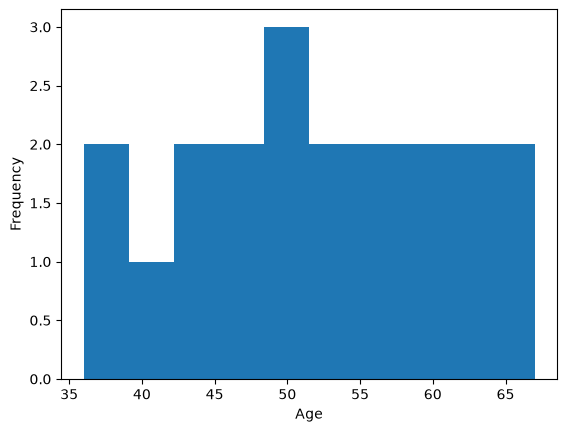

Age的Q-Q图：


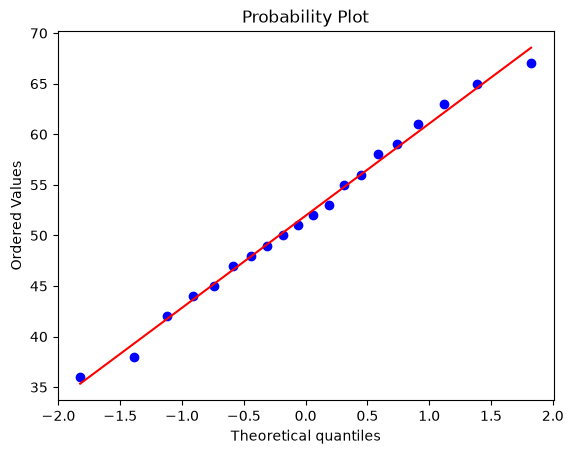

--------------
Tumor_Size的正态分析：
Tumor_Size的p值： 0.9162922826518878
因为Tumor_Size的p值大于0.05，所以没有理由认为Tumor_Size不符合正态分布，因此下一步需要进行t检验。
LN(-)Tumor_Size的p值： 0.15467787397132526
LN(+)Tumor_Size的p值： 0.5763276869391712
Tumor_Size的直方图：


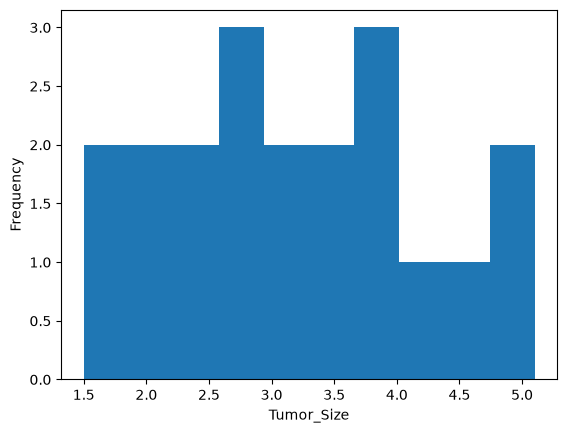

Tumor_Size的Q-Q图：


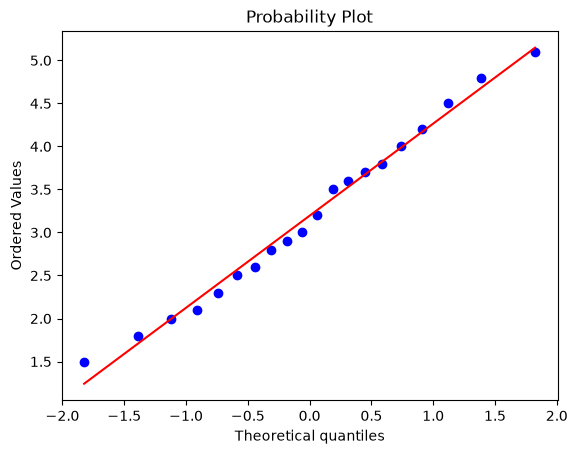

------------
Ki67的正态分析：
Ki67的p值： 0.002156689932776424
因为Ki67的p值小于0.05，因此Ki67不符合正态分布，因此下一步要进行Mann Whitney U检验。
Ki67的直方图：


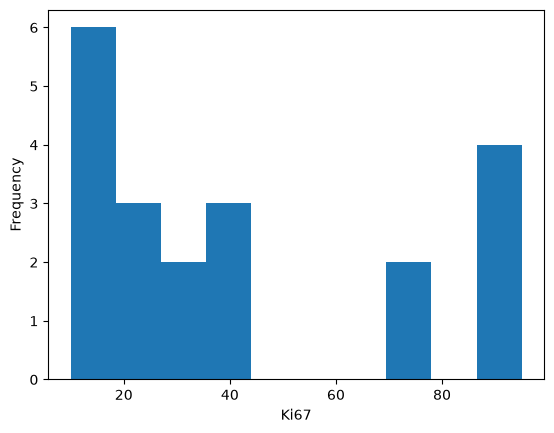

Ki67的Q-Q图：


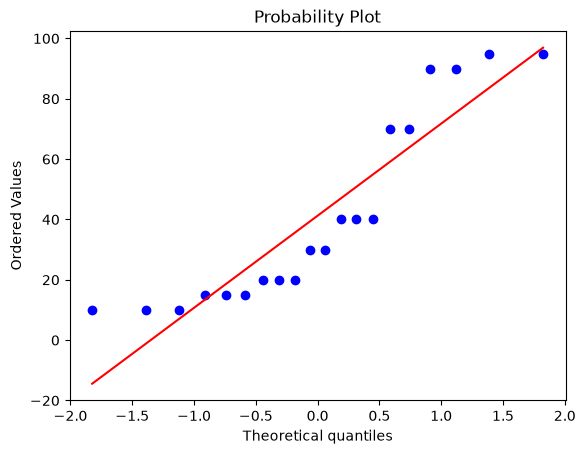

-----------
Age的t检验：
Age_ttest的p值： 0.0017755616146161615
因为Age_ttest的p值小于0.05，所以两组的年龄差异有统计学意义。
-------------
Tumor_Size的t检验：
Tumor_Size_ttest的p值： 0.0007047471803138009
因为Tumor_Size的p值小于0.05，所以两组的肿瘤大小差异有统计学意义。
----------
Ki67的Mann Whitney U检验：
Ki67_U检验的p值： 0.42151799737413176
因为Ki67的p值大于0.05，所以两组的Ki67差异有统计学意义。
-----------
------------分类变量------------
ER与Lymph_Node的交叉表： Lymph_Node     0     1
ER                    
0            5.0  30.0
1           40.0  25.0
PR与Lymph_Node的交叉表： Lymph_Node     0     1
PR                    
0           10.0  45.0
1           35.0  10.0
HER2与Lymph_Node的交叉表： Lymph_Node     0     1
HER2                  
0           35.0  15.0
1           10.0  40.0
-----------
ER的chi square检验：
ER的p值： 1.562979606250842e-05
ER的expected: [[15.75 19.25]
 [29.25 35.75]]
因为样本量太小，因此再进行一次fisher检验。
ER的fisher检验：
ER的p值： 5.937366666164522e-06
因为p值大于0.05，所以ER和淋巴结转移之间没有统计学关联。
------------
PR的chi square检验：
PR的p值： 8.53304779969515e-09
PR的expected: [[24.75 30.25]
 [20.25 24.75]]
因为样本量太小，因此

In [29]:
import pandas as pd
import numpy as np
df=pd.read_csv('breast_cancer_clinical3.csv')
print('breast_cancer_clinical3.csv读取成功')
print('------------')
print('df数据结构：')
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print('-------------')
LN0=df[df['Lymph_Node']==0]
print('LN0的数据结构：')
print(LN0.describe())
print('---------------')
LN1=df[df['Lymph_Node']==1]
print('LN1的数据结构：')
print(LN1.describe())
print('-------------')
print('--------------连续变量----------------')
print('Age的正态分析：')
from scipy.stats import shapiro
stat,p=shapiro(df['Age'])
print('Age的p值：',p)
print('因为Age的p值大于0.05，所以没有理由认为Age不符合正态分布，因此下一步需要进行t检验。')
stat,p=shapiro(LN0['Age'])
print('LN(-)Age的p值：',p)
stat,p=shapiro(LN1['Age'])
print('LN(+)Age的p值：',p)
print('Age的直方图：')
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print('Age的Q-Q图：')
import scipy.stats as stats
stats.probplot(df['Age'],dist='norm',plot=plt)
plt.show()
print('--------------')
print('Tumor_Size的正态分析：')
stat,p=shapiro(df['Tumor_Size'])
print('Tumor_Size的p值：',p)
print('因为Tumor_Size的p值大于0.05，所以没有理由认为Tumor_Size不符合正态分布，因此下一步需要进行t检验。')
stat,p=shapiro(LN0['Tumor_Size'])
print('LN(-)Tumor_Size的p值：',p)
stat,p=shapiro(LN1['Tumor_Size'])
print('LN(+)Tumor_Size的p值：',p)
print('Tumor_Size的直方图：')
plt.hist(df['Tumor_Size'],bins=10)
plt.xlabel('Tumor_Size')
plt.ylabel('Frequency')
plt.show()
print('Tumor_Size的Q-Q图：')
stats.probplot(df['Tumor_Size'],dist='norm',plot=plt)
plt.show()
print('------------')
print('Ki67的正态分析：')
stat,p=shapiro(df['Ki67'])
print('Ki67的p值：',p)
print('因为Ki67的p值小于0.05，因此Ki67不符合正态分布，因此下一步要进行Mann Whitney U检验。')
print('Ki67的直方图：')
plt.hist(df['Ki67'],bins=10)
plt.xlabel('Ki67')
plt.ylabel('Frequency')
plt.show()
print('Ki67的Q-Q图：')
stats.probplot(df['Ki67'],dist='norm',plot=plt)
plt.show()
print('-----------')
from scipy.stats import ttest_ind
print('Age的t检验：')
t,p=ttest_ind(LN0['Age'],LN1['Age'],equal_var=False)
print('Age_ttest的p值：',p)
print('因为Age_ttest的p值小于0.05，所以两组的年龄差异有统计学意义。')
print('-------------')
print('Tumor_Size的t检验：')
t,p=ttest_ind(LN0['Tumor_Size'],LN1['Tumor_Size'],equal_var=False)
print('Tumor_Size_ttest的p值：',p)
print('因为Tumor_Size的p值小于0.05，所以两组的肿瘤大小差异有统计学意义。')
print('----------')
print('Ki67的Mann Whitney U检验：')
from scipy.stats import mannwhitneyu
u,p=mannwhitneyu(LN0['Ki67'],LN1['Ki67'],alternative='two-sided')
print('Ki67_U检验的p值：',p)
print('因为Ki67的p值大于0.05，所以两组的Ki67差异有统计学意义。')
print('-----------')
print('------------分类变量------------')
table1=pd.crosstab(df['ER'],df['Lymph_Node'],normalize=True)*100
print('ER与Lymph_Node的交叉表：',table1)
table2=pd.crosstab(df['PR'],df['Lymph_Node'],normalize=True)*100
print('PR与Lymph_Node的交叉表：',table2)
table3=pd.crosstab(df['HER2'],df['Lymph_Node'],normalize=True)*100
print('HER2与Lymph_Node的交叉表：',table3)
print('-----------')
from scipy.stats import chi2_contingency
print('ER的chi square检验：')
chi,p,dof,expected=chi2_contingency(table1)
print('ER的p值：',p)
print('ER的expected:',expected)
print('因为样本量太小，因此再进行一次fisher检验。')
print('ER的fisher检验：')
from scipy.stats import fisher_exact
oddsratio,p=fisher_exact(table1)
print('ER的p值：',p)
print('因为p值大于0.05，所以ER和淋巴结转移之间没有统计学关联。')
print('------------')
print('PR的chi square检验：')
chi,p,dof,expected=chi2_contingency(table2)
print('PR的p值：',p)
print('PR的expected:',expected)
print('因为样本量太小，因此再进行一次fisher检验。')
print('PR的fisher检测：')
oddsratio,p=fisher_exact(table2)
print('PR的p值：',p)
print('因为p值小于0.05，所以PR与淋巴结转移之间有统计学关联。')
print('------------')
print('HER2的chi square:')
chi,p,dof,expected=chi2_contingency(table3)
print('HER2的p值：',p)
print('HER2的expected:',expected)
print('因为样本量太小，因此再进行一次fisher检验。')
print('HER2的fisher检测：')
oddsratio,p=fisher_exact(table3)
print('HER2的p值：',p)
print('因为p值大于0.05，所以HER2和淋巴结转移有统计学关联。')
print('-------------')
print('---------Table1 Baseline Characteristics---------')
Table1=pd.DataFrame({
    'Variable':['Age','Tumor_Size','Ki67','ER','PR','HER2'],
    'Overall':['51.95±8.67','3.20±1.02','30(15,70)','20','20','20'],
    'LN(-)':['45.67±7.33','2.42±0.78','20(15,40)','45%','45%','455'],
    'LN(+)':['57.09±5.92','3.83±0.72','45.45±31.89','55%','55%','55%']
})
print(Table1)
Table1.to_excel('Baseline Characteristics Table1.xlsx')
print('Baseline Characteristics Table1.xlsx保存成功')
print('------------')
print('--------Univariate Logistic Regression Analysis-------')
import statsmodels.api as sm
uni_results=[]
variables=['Age','Tumor_Size','Ki67','ER','PR','HER2']
for variable in variables:
    y=df['Lymph_Node']
    X=df[[variable]]
    X=sm.add_constant(X)
    model=sm.Logit(y,X).fit(disp=False)
    beta=model.params[variable]
    OR=np.exp(model.params[variable])
    CI=np.exp(model.conf_int().loc[variable])
    p=model.pvalues[variable]
    uni_results.append([
        variable,
        OR,
        CI[0],
        CI[1],
        p
    ])
Uni_table=pd.DataFrame(
    uni_results,
    columns=[
        'Variables',
        'Uni_OR',
        'Uni_95%CI_low',
        'Uni_95%CI_high',
        'Uni_P'
    ])
print('Univariate Logistic Regression Analysis Table:')
print(Uni_table)
print('-----------')
print('-------Multivariate Logistic Regression Analysis--------')
multi_results=[]
y=df['Lymph_Node']
X=df[['Age','Tumor_Size','Ki67','ER','PR','HER2']]
X=sm.add_constant(X)
model=sm.Logit(y,X).fit(disp=False)
for variable in variables:
    OR=np.exp(model.params[variable])
    CI=np.exp(model.conf_int().loc[variable])
    p=model.pvalues[variable]
    multi_results.append([
        variable,
        OR,
        CI[0],
        CI[1],
        p
    ])
Multi_table=pd.DataFrame(
    multi_results,
    columns=[
        'Variables',
        'Multi_OR',
        'Multi_95%CI_low',
        'Multi_95%CI_high',
        'Multi_P'
    ])
print('Multivariate Logistic Regression Analysis Table:')
print(Multi_table)
print('-----------')
final_table=pd.merge(Uni_table,Multi_table,on='Variables')
print('--------final_table----------')
final_table['Uni_OR_CI']=(final_table['Uni_OR'].round(2).astype(str)
                          +
                          '('
                          +
                          final_table['Uni_95%CI_low'].round(2).astype(str)
                          +
                          '-'
                          +
                          final_table['Uni_95%CI_high'].round(2).astype(str)
                          +
                          ')')
final_table['Multi_OR_CI']=(final_table['Multi_OR'].round(2).astype(str)
                            +
                            '('
                            +
                            final_table['Multi_95%CI_low'].round(2).astype(str)
                            +
                            '-'
                            +
                            final_table['Multi_95%CI_high'].round(2).astype(str)
                            +
                            ')')
print(final_table)
print('---------------')
print('-------paper table-------')
paper_table=final_table[['Variables','Uni_OR_CI','Uni_P','Multi_OR_CI','Multi_P']]
print(paper_table)
paper_table.to_excel('paper_table.xlsx')
print('paper_table.xlsx保存成功')







